# Tests for `calculate_native_gradient_tracer`

This notebook demonstrates the unit tests in
`tests/test_native_gradient_tracer.py` for
`dbof.utils.native_gradient.calculate_native_gradient_tracer`.

The function takes a tracer field and returns its horizontal gradient as
east-west (zonal, λ) and north-south (meridional, φ) components. On the native
LLC grid that takes three steps, and the notebook is organised around checking
each:

1. **difference and divide** — subtract adjacent tracer values, divide by the
   distance between them. The difference lands on the cell face; the spacing
   metric (`dxC`, `dyC`) is defined on that same face.
2. **interpolate to cell centres** — the two half-gradients move from the U and
   V points back to the tracer point.
3. **rotate** — the vector is rotated from the grid's x/y axes into east/north
   using `CS`/`SN`, which are stored at tracer points.

## Conventions

* **λ = longitude** (zonal, positive eastward), **φ = latitude** (meridional,
  positive northward) — the ECCO convention used throughout dbof and in the
  ECCO v4 tutorial this code comes from. Note this differs from the physics
  habit of writing (θ, φ); we keep the ECCO naming because the production
  outputs (`grad_lambda`, `grad_phi`) already use it.
* **Model frame vs geographic frame.** The LLC grid's local x/y axes are
  rotated relative to east/north by an angle α that varies over the globe; the
  grid stores `CS = cos α`, `SN = sin α` at cell centres. "Model frame" means
  components along the grid's own x/y; "geographic frame" means
  zonal/meridional.
* **All output lands on tracer points (cell centres).** Anything needing the
  gradient on U/V points must interpolate it itself. Section 1 shows where each
  operation happens on the cell.
* `slope_x`, `slope_y` are prescribed synthetic tracer slopes (tracer units per
  metre) used to build linear test fields — **not** pressure or any physical
  variable.

  

Generated by JXP, LH and Claude


## How "computed" and "analytic" are produced

Every test in this notebook compares two numbers at the same point:

* **computed** — the output of `calculate_native_gradient_tracer`, the
  production function. Nothing about how it works is assumed.
* **analytic** — the correct answer, derived on paper from the definition of
  the test field and evaluated by a separate one-line expression in the test
  module. **It never calls the function under test.**

That separation is the point: a function can only be checked against a truth
obtained some other way. So the design problem in each section is choosing a
test field whose gradient can be written down in closed form. Two families are
used.

### A. Linear tracer on a synthetic grid — Sections 2, 3, 4

Build a grid whose metrics and rotation are constants *we* choose, and set the
tracer to `s = slope_x·x + slope_y·y`, where x and y are the model's own axes.
Then by construction:

* `∂s/∂x = slope_x` and `∂s/∂y = slope_y`, exactly, at every point;
* rotating into geographic components gives
  `(grad_λ, grad_φ) = R · (slope_x, slope_y)` with `R = [[CS, −SN], [SN, CS]]`.

That is the entire analytic side — in the test module it is literally

```python
def analytic_rotated_gradient(slope_x, slope_y, cs, sn):
    return slope_x*cs - slope_y*sn,  slope_x*sn + slope_y*cs
```

**Why linear:** finite differences and linear interpolation are *exact* on a
linear field, so there is no truncation error to confuse with a bug. Any
deviation from the analytic value is either a bug or floating-point round-off,
and round-off is ~1e-19. That is what lets Sections 2–4 assert equality to
machine precision rather than to a tolerance.

### B. Analytic function of latitude/longitude on the real grid — Section 7

On the real grid we do not get to choose the metrics or the rotation, so
instead we choose the tracer as a function of position on the sphere whose
geographic gradient is known from vector calculus:

| tracer | true east-west gradient | true north-south gradient |
|---|---|---|
| `s = sin φ` | **0** (exactly) | `cos φ / R` |
| `s = sin λ cos φ` | `cos λ / R` | `−sin λ sin φ / R` |

These fields have curvature, so finite differencing is *not* exact — but at
1/48° the truncation error works out to ~2e-8 in the normalised units of
Section 7, four orders of magnitude below the float32 noise floor. The
comparison is still meaningful; it just isn't exact, which is why Section 7
uses tolerances and Sections 2–4 do not.

### Where each one is used

| section | grid | tracer | analytic truth |
|---|---|---|---|
| 2 | synthetic, isotropic, 45° | linear | `R·(slope_x, slope_y)` |
| 3 | synthetic, isotropic, 5 angles | linear | same, swept over α |
| 4 | synthetic, **anisotropic** | linear | same, plus the predicted *wrong* answer |
| 7 | **real** | `sin φ`, `sin λ cos φ` | closed-form spherical gradients |
| 6, 8 | real | real `Theta` | none — these are not analytic comparisons |


In [ ]:
# Imports at top (project convention). We import the test module itself
# so every figure is generated from the exact fixtures and helpers the
# unit tests assert on.
import os
import sys
import warnings

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.join('..', '..', 'tests'))
import test_native_gradient_tracer as tgt
from cgrid_schematic import draw_cgrid_schematic
import dbof.utils.native_gradient as ng
from dbof.llc4320_ingestion.grid import set_xgcm_grid


## 1. Where each operation lives on the cell

**What we're testing:** nothing — this is the reference diagram for reading
every other figure. LLC4320 uses an **Arakawa C grid**. A 2×2 block of cells with each point type in ECCO/xmitgcm
naming: tracer `(j, i)`, U `(j, i_g)` on the west face, V `(j_g, i)` on the
south face, corner `(j_g, i_g)`, and arrows tracing the three steps above.

**What to take from it:** The schematic shows every point type and the exact path of the
tracer-gradient computation: `grid.diff` lands the x-difference on the
**U point** `(j, i_g)` where `dxC` is defined (and the y-difference on
the **V point** `(j_g, i)` with `dyC`), `grid.interp` brings each
half-gradient back to the **tracer point** `(j, i)`, and the rotation
by `CS`/`SN` (stored at tracer points) happens there. **Everything this
routine returns therefore lives at tracer/cell-centre points.** 


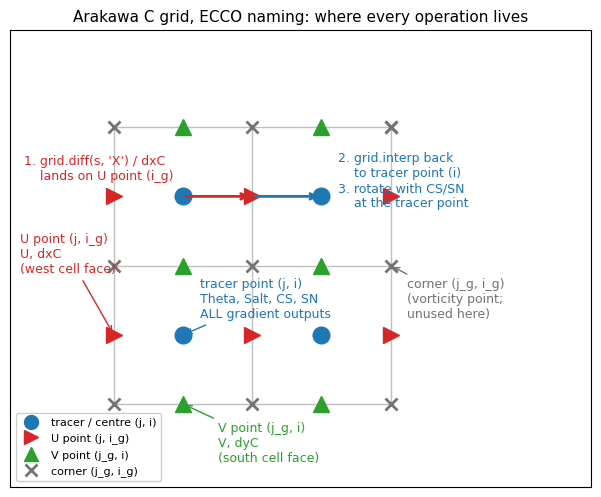

In [ ]:
ax = draw_cgrid_schematic()
plt.show()


## 2. End-to-end against an analytic answer

**What we're testing:** the whole calculation end to end, on a synthetic case
with an exact known answer (family A above).

**How it's set up:** a synthetic 13-face grid reproduces the 
full 13-face LLC topology using the production
`face_connections`, so cross-face stitching is genuinely exercised, but
simplified: **uniform
metrics** (`dxC = dyC = 2500 m`) and **spatially constant** rotation
coefficients, so the expected answer is a closed form. It is
*isotropic by default*; Section 4 uses an **anisotropic** variant
(`dyC ≠ dxC`) precisely because grid anisotropy is what catches
metric-swap errors that an isotropic grid cannot see.* A linear
tracer `s = slope_x·x + slope_y·y`, is applied. Finite differences and linear
interpolation are exact, so each face's interior must equal the
analytic rotated gradient `R·(slope_x, slope_y)` to machine precision.

**How to tell it worked:**

* Top two panels (east-west and north-south components): a single flat colour
  inside the dashed red box, matching the "analytic =" value in the title.
* Bottom two panels (error): blank inside the dashed box; printed max interior
  error ~1e-19.
* **What a failed test looks like:** any pattern inside the dashed box, or a
  uniform bright colour in the error panels (right structure, wrong value).

**How to read the face edges: the edge ring looks alarming and isn't.** Each of the 13
faces carries its *own* linear field, so the `face_connections` halo stitches
inconsistent neighbours together at every seam: the outer ring of every face is
wrong **by construction**. That is what the dashed `EDGE_MARGIN` box marks, and
why the tests and the error statistics exclude it. On the *real* grid a smooth
global field has no such seam problem — Section 7 exploits exactly that.


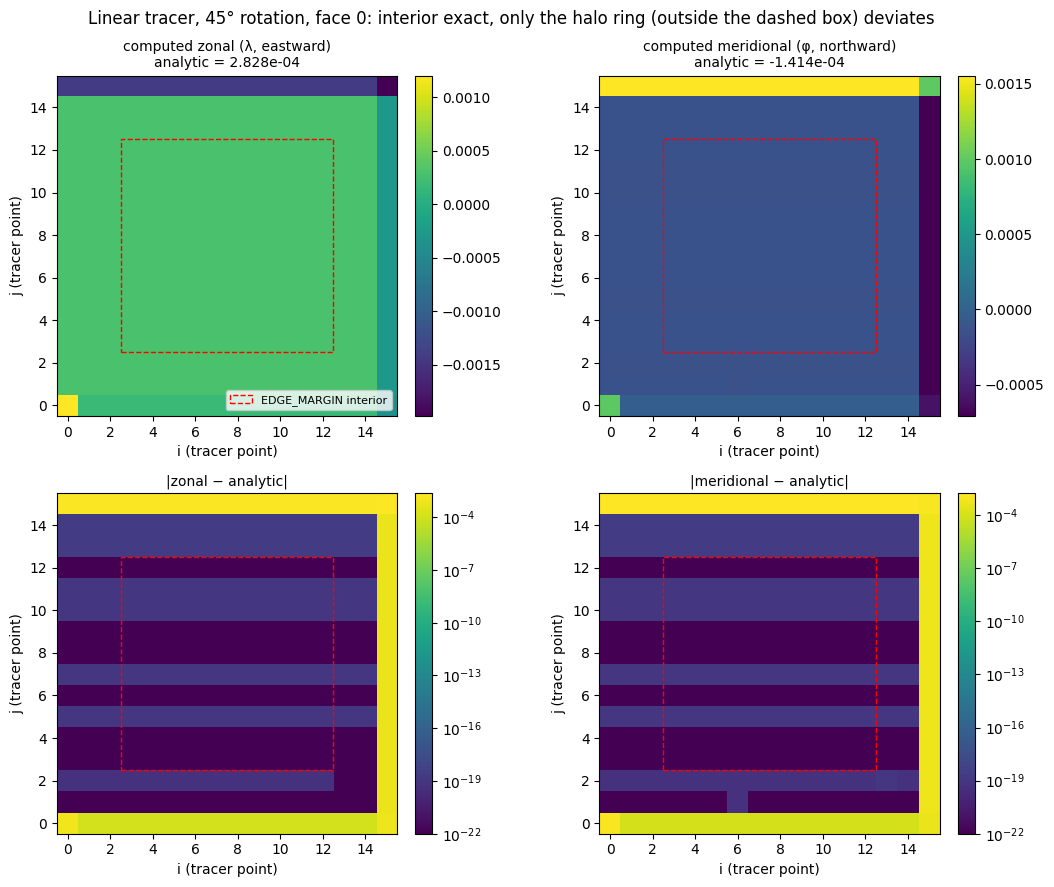

max interior |error|: zonal 1.08e-19, meridional 1.08e-19  (machine precision)


In [ ]:
d = 2500.0
slope_x, slope_y = 1.0e-4, -3.0e-4
alpha = np.radians(45.0)
cs, sn = np.cos(alpha), np.sin(alpha)

ds_syn, grid_syn = tgt.make_synthetic_grid(n=16, d=d, cs=cs, sn=sn)
s_lin = tgt.add_linear_tracer(ds_syn, d, slope_x, slope_y)
gl, gp = ng.calculate_native_gradient_tracer(s_lin, ds_syn, grid_syn)
t_l, t_p = tgt.analytic_rotated_gradient(slope_x, slope_y, cs, sn)

m = tgt.EDGE_MARGIN
n = ds_syn.sizes['i']
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
panels = [
    (gl.isel(face=0).values, f'computed zonal (λ, eastward)\n'
     f'analytic = {t_l:.3e}', None),
    (gp.isel(face=0).values, f'computed meridional (φ, northward)\n'
     f'analytic = {t_p:.3e}', None),
    (np.abs(gl.isel(face=0).values - t_l), '|zonal − analytic|', LogNorm()),
    (np.abs(gp.isel(face=0).values - t_p), '|meridional − analytic|',
     LogNorm()),
]
for ax, (img, title, norm) in zip(axes.ravel(), panels):
    if norm is not None:
        img = np.clip(img, 1e-22, None)
    pcm = ax.imshow(img, origin='lower', norm=norm, cmap='viridis')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.add_patch(mpatches.Rectangle((m - 0.5, m - 0.5),
                 n - 2 * m, n - 2 * m, fill=False, ls='--', ec='r',
                 label='EDGE_MARGIN interior'))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('i (tracer point)')
    ax.set_ylabel('j (tracer point)')
axes[0, 0].legend(loc='lower right', fontsize=8)
fig.suptitle('Linear tracer, 45° rotation, face 0: interior exact, '
             'only the halo ring (outside the dashed box) deviates')
fig.tight_layout()
plt.show()

int_err_l = np.abs(tgt.interior(gl).values - t_l).max()
int_err_p = np.abs(tgt.interior(gp).values - t_p).max()
print(f'max interior |error|: zonal {int_err_l:.2e}, '
      f'meridional {int_err_p:.2e}  (machine precision)')


## 3. Rotation across a sweep of angles

**What we're testing:** step 3 — the rotation from the **model frame** (the
grid's own x/y axes) into the **geographic frame** (east/north) — across a
range of angles rather than the single 45° of Section 2.

**How it's set up:** the same synthetic grid and linear tracer, rebuilt five
times with the model axes rotated by α = 0°, 30°, 45°, 90°, 137° relative to
east/north, where `CS = cos α`, `SN = sin α`.

**What the left panel is showing.** The x-axis is the rotation angle α; the
y-axis is the value of a gradient component.

* The two **solid curves** are the analytic components as continuous functions
  of α — `slope_x·cos α − slope_y·sin α` and `slope_x·sin α + slope_y·cos α`,
  evaluated on a fine sweep. They are sinusoids because `R` is a rotation: as
  the grid turns, a fixed physical gradient projects onto east and north in a
  smoothly varying way.
* The **markers** are the computed values at the five angles actually tested.
* "Computed interior mean" means: run the function, throw away the
  `EDGE_MARGIN` ring, and average what is left on face 0. Because the interior
  is a single constant by construction, that average *is* that constant — it is
  just a way to put one number per angle on the plot. Averaging is only safe
  here because the right panel separately reports the **maximum** deviation; on
  a field that was not uniform, a mean could hide a large error.

So the left panel answers "is the rotation right?" and the right panel answers
"is it right everywhere, not just on average?".

**Why 0° and 90° are in the list:**

* **α = 0°** (`CS = 1, SN = 0`): `R` is the identity — model x is east, model y
  is north, and the components should pass through unchanged. Catches a
  rotation being applied when none should be.
* **α = 90°** (`CS = 0, SN = 1`): model x points **north**, model y points
  **west**. So the east-west output must equal *minus* the model y-gradient and
  the north-south output must equal *plus* the model x-gradient. A dropped
  minus sign is unambiguous here.
* At **45°** both model axes contribute equally to both outputs, so a component
  swap and a sign flip give nearly identical numbers — which is exactly why
  Section 2's single angle is not sufficient on its own.

**How to tell it worked:**

* Left panel: every marker on its own curve, at all five angles.
* Right panel: max error ~1e-19 at every angle.
* **What a failed test looks like:** a marker off its curve; a circle sitting
  on the square's curve (components swapped); a marker mirrored about zero
  (sign flip in `R`); right-panel errors at 1e-4 or larger.


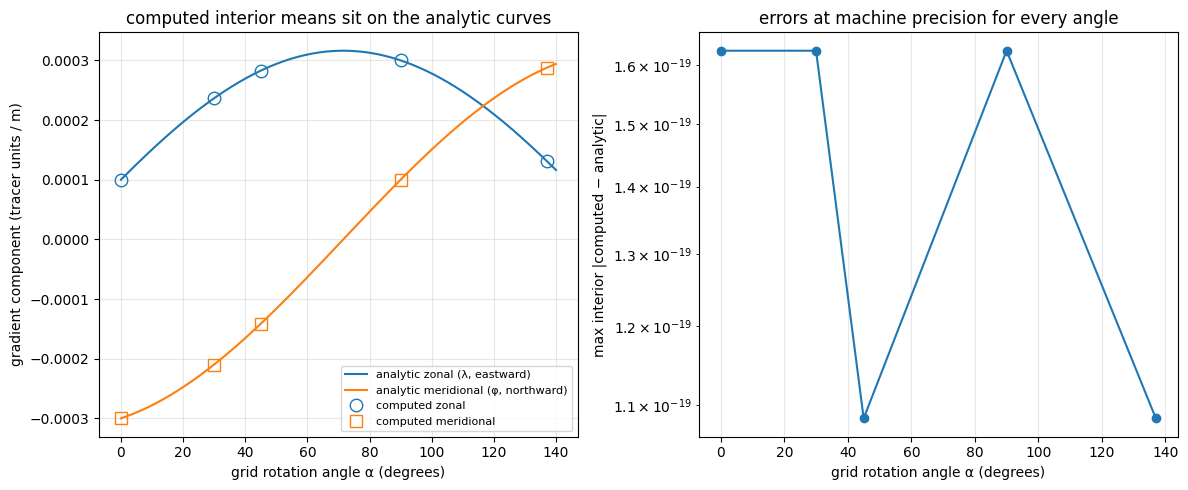

In [ ]:
angles = np.array([0.0, 30.0, 45.0, 90.0, 137.0])
comp_l, comp_p, ana_l, ana_p, maxerr = [], [], [], [], []
for a_deg in angles:
    a = np.radians(a_deg)
    ca, sa = np.cos(a), np.sin(a)
    dsx, gx = tgt.make_synthetic_grid(n=16, d=d, cs=ca, sn=sa)
    sx = tgt.add_linear_tracer(dsx, d, slope_x, slope_y)
    gla, gpa = ng.calculate_native_gradient_tracer(sx, dsx, gx)
    tl, tp = tgt.analytic_rotated_gradient(slope_x, slope_y, ca, sa)
    comp_l.append(float(tgt.interior(gla).mean()))
    comp_p.append(float(tgt.interior(gpa).mean()))
    ana_l.append(tl)
    ana_p.append(tp)
    maxerr.append(max(np.abs(tgt.interior(gla).values - tl).max(),
                      np.abs(tgt.interior(gpa).values - tp).max()))

fine = np.linspace(0, 140, 300)
fl = slope_x * np.cos(np.radians(fine)) - slope_y * np.sin(np.radians(fine))
fp = slope_x * np.sin(np.radians(fine)) + slope_y * np.cos(np.radians(fine))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fine, fl, '-', color='C0',
             label='analytic zonal (λ, eastward)')
axes[0].plot(fine, fp, '-', color='C1',
             label='analytic meridional (φ, northward)')
axes[0].plot(angles, comp_l, 'o', color='C0', ms=9, mfc='none',
             label='computed zonal')
axes[0].plot(angles, comp_p, 's', color='C1', ms=9, mfc='none',
             label='computed meridional')
axes[0].set_xlabel('grid rotation angle α (degrees)')
axes[0].set_ylabel('gradient component (tracer units / m)')
axes[0].set_title('computed interior means sit on the analytic curves')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].semilogy(angles, maxerr, 'o-')
axes[1].set_xlabel('grid rotation angle α (degrees)')
axes[1].set_ylabel('max interior |computed − analytic|')
axes[1].set_title('errors at machine precision for every angle')
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 4. Anisotropic metrics: is `dxC` paired with the x-difference?

**What we're testing:** that the x-difference is divided by `dxC` and the
y-difference by `dyC`, not crossed over.

**How it's set up:** on an isotropic grid (`dxC = dyC`) this error is
numerically invisible — both divisions give identical results. So the synthetic
grid is rebuilt with `dyC = 2.4 dxC` (2500 m × 6000 m), at α = 0° and 30°.

**What the three things on the bar chart are:**

| plotted as | source | what it is |
|---|---|---|
| **computed** (blue) | `calculate_native_gradient_tracer` | what the code produced |
| **analytic** (grey) | `analytic_rotated_gradient()` | the paper answer (family A above) |
| **swapped metrics** (red ×) | the same expression with `slope_x·dxC/dyC`, `slope_y·dyC/dxC` | the answer you would get *if the bug were present* |

Plotting the predicted failure alongside is what makes this figure diagnostic
rather than merely reassuring — you can see how far a pass sits from the
failure mode.

**How to tell it worked:** grey and blue bars the same height in each group,
red ×s visibly elsewhere.

* **What a failed test looks like:** blue bars on the red ×s, or at any height
  other than grey.

**Not covered:** an error scaling *both* metrics equally (e.g. a unit error).


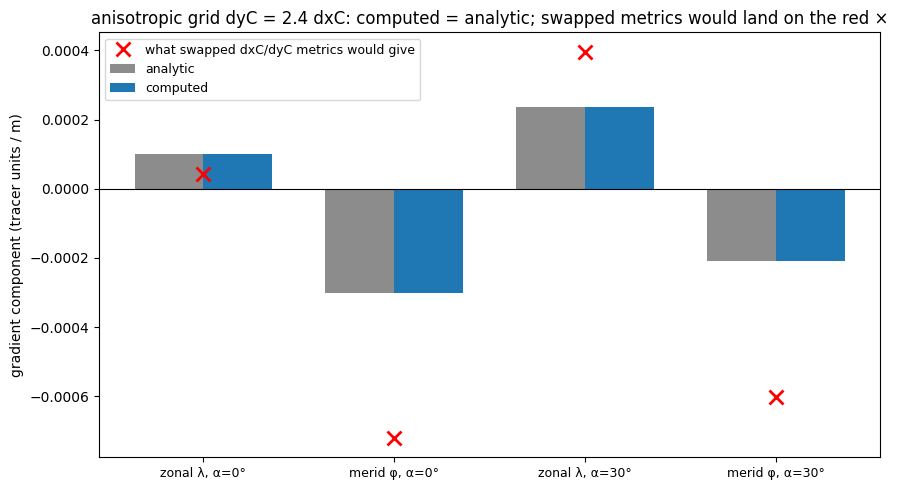

zonal λ, α=0°      computed +1.000000e-04  analytic +1.000000e-04
merid φ, α=0°      computed -3.000000e-04  analytic -3.000000e-04
zonal λ, α=30°     computed +2.366025e-04  analytic +2.366025e-04
merid φ, α=30°     computed -2.098076e-04  analytic -2.098076e-04


In [ ]:
dy = 6000.0                                     # dyC = 2.4 dxC
labels, computed, analytic, swapped = [], [], [], []
for a_deg in (0.0, 30.0):
    a = np.radians(a_deg)
    ca, sa = np.cos(a), np.sin(a)
    dsa, ga = tgt.make_synthetic_grid(n=16, d=d, cs=ca, sn=sa, dy=dy)
    sa_ = tgt.add_linear_tracer(dsa, d, slope_x, slope_y, dy=dy)
    gla, gpa = ng.calculate_native_gradient_tracer(sa_, dsa, ga)
    tl, tp = tgt.analytic_rotated_gradient(slope_x, slope_y, ca, sa)
    # What swapped metrics would produce: dividing the x-difference by
    # dyC scales the model-x gradient by dx/dy (1/2.4) and the model-y
    # gradient by dy/dx (2.4) BEFORE the rotation mixes them.
    tl_s, tp_s = tgt.analytic_rotated_gradient(
        slope_x * d / dy, slope_y * dy / d, ca, sa)
    labels += [f'zonal λ, α={a_deg:.0f}°', f'merid φ, α={a_deg:.0f}°']
    computed += [float(tgt.interior(gla).mean()),
                 float(tgt.interior(gpa).mean())]
    analytic += [tl, tp]
    swapped += [tl_s, tp_s]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.18, analytic, width=0.36, label='analytic', color='0.55')
ax.bar(x + 0.18, computed, width=0.36, label='computed', color='C0')
ax.plot(x, swapped, 'rx', ms=10, mew=2,
        label='what swapped dxC/dyC metrics would give')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('gradient component (tracer units / m)')
ax.set_title('anisotropic grid dyC = 2.4 dxC: computed = analytic; '
             'swapped metrics would land on the red ×')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
for lab, c, t in zip(labels, computed, analytic):
    print(f'{lab:18s} computed {c:+.6e}  analytic {t:+.6e}')


## 5. Online: the real LLC4320 grid and the surface tracer (metadata)

The real grid (rotation coefficients `CS`/`SN`, metrics `dxC`/`dyC`,
land mask `hFacC`, cell-centre longitude `XC` / latitude `YC`) comes
from `s3://dbof/LLC4320/grid.zarr`, cached locally. The tracer is the
MITgcm variable **`Theta` — potential temperature** (see the metadata
printed below, taken from the store itself); its surface level
(k = 0) is what we refer to as SST here. Distinguishing potential from
in-situ temperature matters little at the surface but would matter at
depth, so we say exactly what the variable is.


In [ ]:
gr = tgt.load_real_llc_grid()
grid_r = set_xgcm_grid(gr.drop_vars('hFacC'), use_connections=True)
theta = tgt.load_real_llc_surface_tracer()
theta = theta.assign_coords(
    {c: gr.coords[c] for c in theta.dims if c in gr.coords})

print('Tracer variable metadata (from the OSN store):')
for key, val in theta.attrs.items():
    print(f'  {key:14s} = {val}')
print(f'  dims           = {theta.dims}  (tracer/cell-centre points)')
print(f'  shape          = {theta.shape}')

# Geographic-frame and model-frame gradients of surface Theta.
gx_g, gy_g = ng.calculate_native_gradient_tracer(theta, gr, grid_r)
gx_m, gy_m = tgt.model_frame_gradient(theta, gr, grid_r)
mag_g = np.sqrt(gx_g ** 2 + gy_g ** 2)
mag_m = np.sqrt(gx_m ** 2 + gy_m ** 2)
print('gradients computed (geographic and model frames), '
      'outputs on dims:', gx_g.dims)


Tracer variable metadata (from the OSN store):
  long_name      = Potential Temperature
  standard_name  = THETA
  units          = degC
  dims           = ('face', 'j', 'i')  (tracer/cell-centre points)
  shape          = (13, 4320, 4320)


gradients computed (geographic and model frames), outputs on dims: ('face', 'j', 'i')


## 6. Online: SST gradients in three regions, at full native resolution

Per the review (and the regions suggested in issue #24), the single
downsampled face map is replaced by **full-resolution** regional
images: every pixel below is one native 1/48° grid cell — no
downsampling, so systematic errors would be visible. For each region
we show the **zonal (λ, eastward)** and **meridional (φ, northward)**
gradient components of surface potential temperature (`Theta`, K/m,
signed, symmetric colour scale) and the gradient magnitude (log
scale). Note in the ±5° Eastern Pacific panel how the meridional
component changes sign across the equator (the tropical instability
wave fronts) while nothing discontinuous happens at the equator
itself — the equatorial symmetry the review asked to be able to check.

Land is white (`hFacC = 0`); these are **SST gradients** (the word
"front" is avoided per the review).


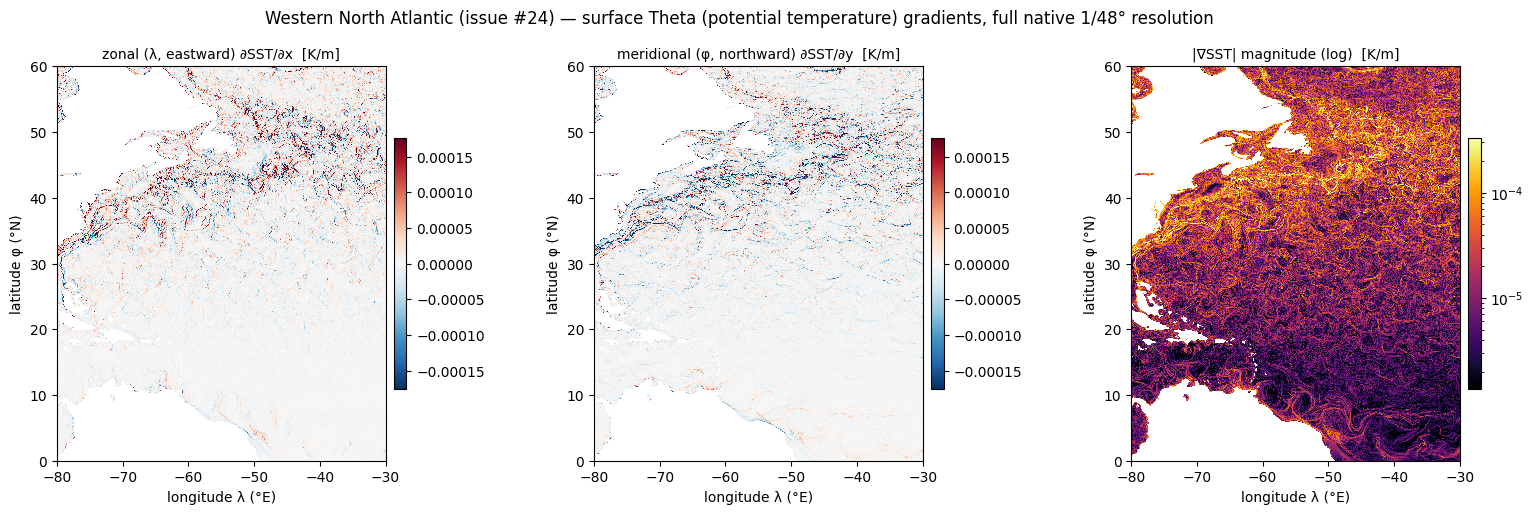

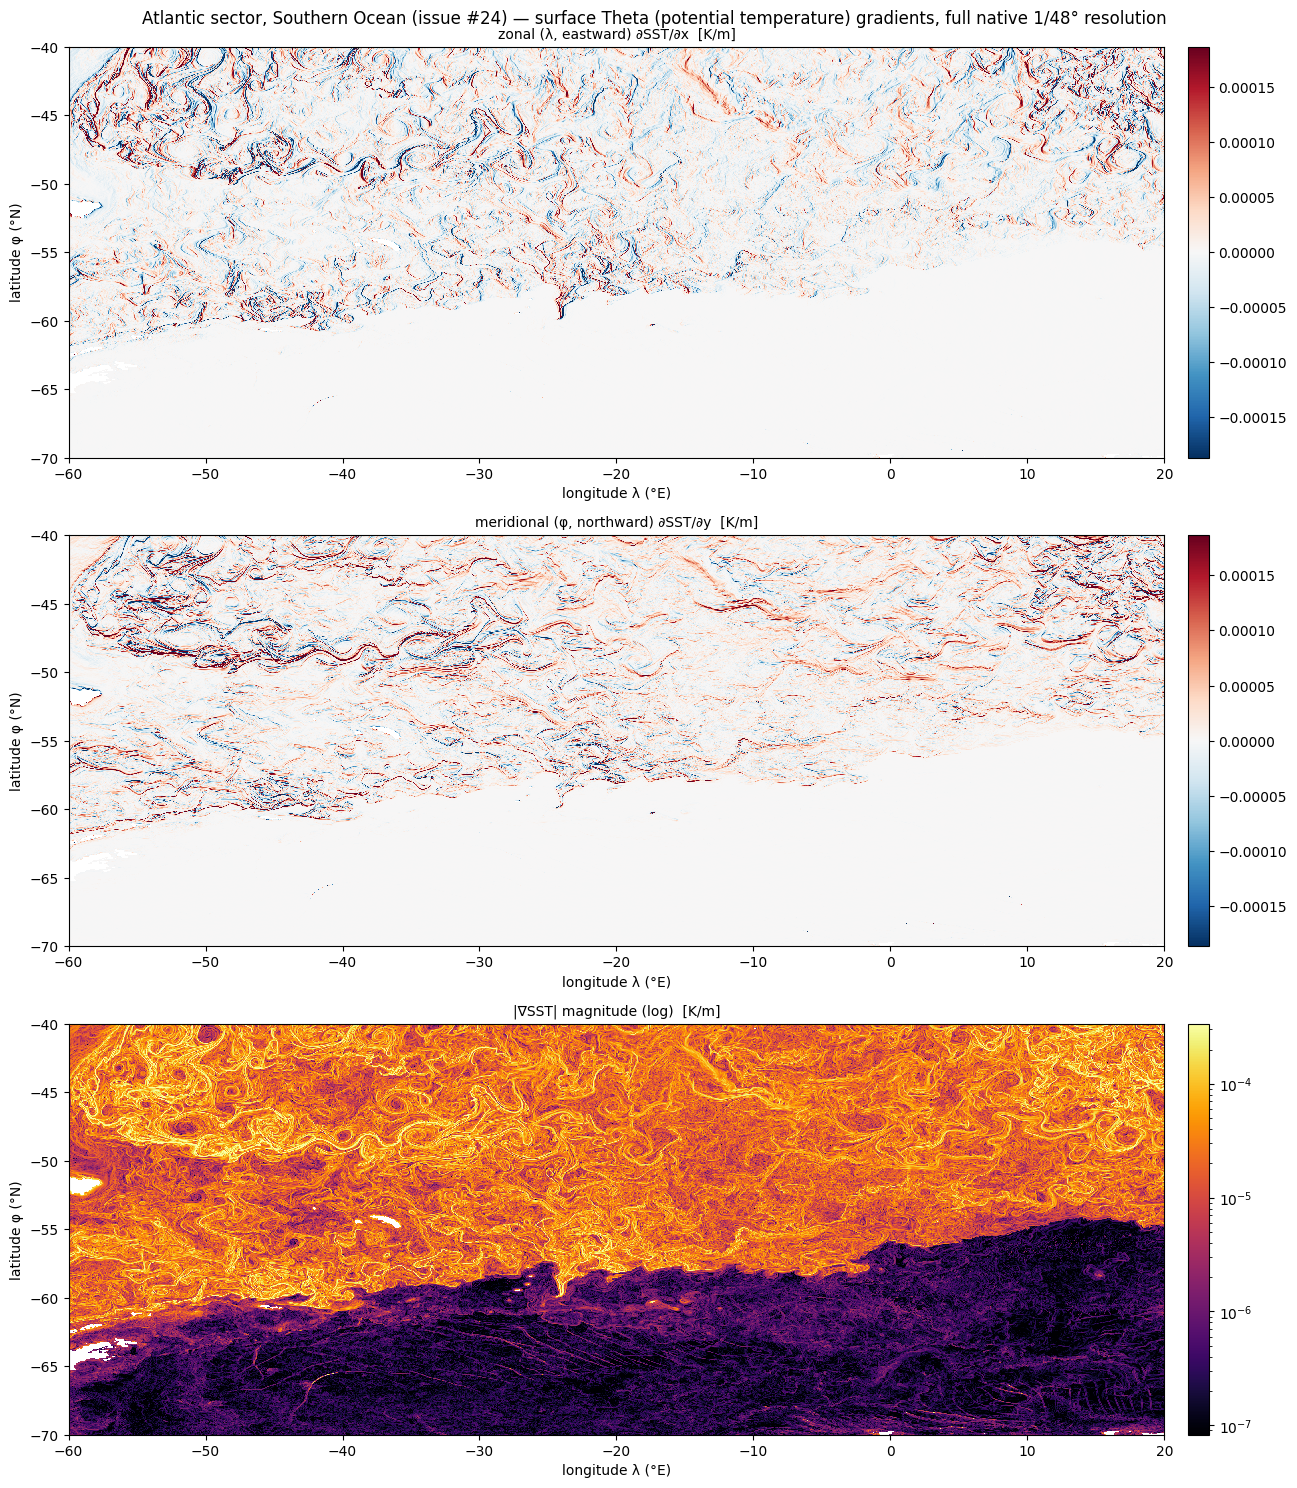

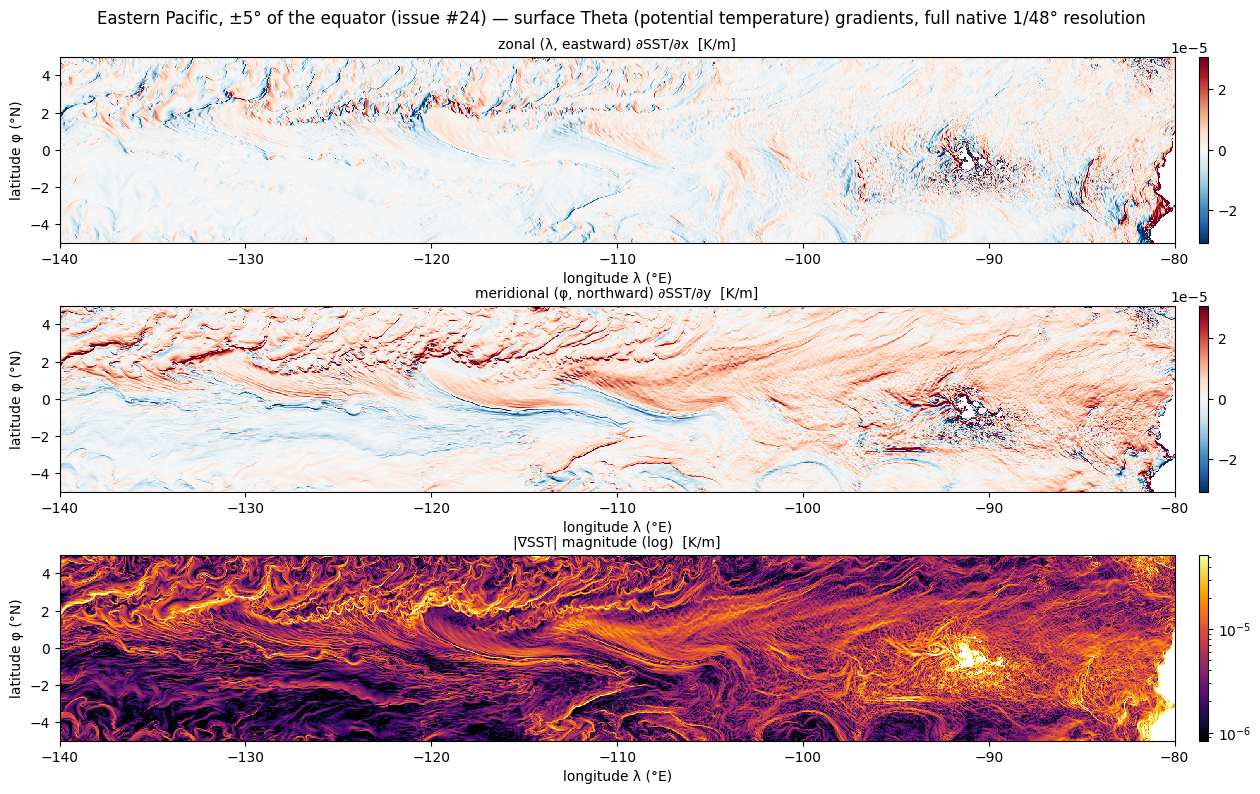

In [ ]:
RES = 1.0 / 48.0                    # native LLC4320 resolution (deg)
REGIONS = [
    ('Western North Atlantic (issue #24)', -80.0, -30.0, 0.0, 60.0),
    ('Atlantic sector, Southern Ocean (issue #24)', -60.0, 20.0,
     -70.0, -40.0),
    ('Eastern Pacific, ±5° of the equator (issue #24)', -140.0, -80.0,
     -5.0, 5.0),
]

lon_all = gr['XC'].values
lat_all = gr['YC'].values
ocean_all = gr['hFacC'].values > 0


def region_image(vals_by_face, lon0, lon1, lat0, lat1):
    """Bin native cells onto a regular lon/lat image at native res.

    Every native grid cell inside the box contributes to exactly one
    output pixel of size 1/48 deg (pixels sharing two cells average
    them), so the image is at the model's own resolution -- no
    downsampling.

    Generated by JXP and Claude
    """
    nx = int(round((lon1 - lon0) / RES))
    ny = int(round((lat1 - lat0) / RES))
    num = np.zeros((ny, nx))
    cnt = np.zeros((ny, nx))
    for f in range(13):
        v = vals_by_face[f]
        m = ((lon_all[f] >= lon0) & (lon_all[f] < lon1) &
             (lat_all[f] >= lat0) & (lat_all[f] < lat1) &
             ocean_all[f] & np.isfinite(v))
        if not m.any():
            continue
        ix = np.clip(((lon_all[f][m] - lon0) / RES).astype(int),
                     0, nx - 1)
        iy = np.clip(((lat_all[f][m] - lat0) / RES).astype(int),
                     0, ny - 1)
        np.add.at(num, (iy, ix), v[m].astype('float64'))
        np.add.at(cnt, (iy, ix), 1.0)
    with np.errstate(invalid='ignore'):
        return np.where(cnt > 0, num / np.maximum(cnt, 1.0), np.nan)


gxv, gyv, mgv = gx_g.values, gy_g.values, mag_g.values
for name, lon0, lon1, lat0, lat1 in REGIONS:
    img_z = region_image(gxv, lon0, lon1, lat0, lat1)
    img_m = region_image(gyv, lon0, lon1, lat0, lat1)
    img_a = region_image(mgv, lon0, lon1, lat0, lat1)
    ext = (lon0, lon1, lat0, lat1)
    vlim = np.nanpercentile(np.abs(img_m), 99.0)
    pos = img_a[np.isfinite(img_a) & (img_a > 0)]

    box_aspect = (lat1 - lat0) / (lon1 - lon0)
    if box_aspect < 0.5:                # much wider than tall: stack
        pw = 11.5
        ph = max(pw * box_aspect, 1.6)
        fig, axes = plt.subplots(3, 1,
                                 figsize=(pw + 1.5, 3 * ph + 2.2))
    else:                               # tall boxes: side by side
        fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
    p0 = axes[0].imshow(img_z, origin='lower', extent=ext, cmap='RdBu_r',
                        vmin=-vlim, vmax=vlim, interpolation='nearest')
    axes[0].set_title('zonal (λ, eastward) ∂SST/∂x  [K/m]', fontsize=10)
    p1 = axes[1].imshow(img_m, origin='lower', extent=ext, cmap='RdBu_r',
                        vmin=-vlim, vmax=vlim, interpolation='nearest')
    axes[1].set_title('meridional (φ, northward) ∂SST/∂y  [K/m]',
                      fontsize=10)
    p2 = axes[2].imshow(img_a, origin='lower', extent=ext, cmap='inferno',
                        norm=LogNorm(vmin=np.percentile(pos, 5),
                                     vmax=np.percentile(pos, 99.5)),
                        interpolation='nearest')
    axes[2].set_title('|∇SST| magnitude (log)  [K/m]', fontsize=10)
    for ax, pcm in zip(axes, (p0, p1, p2)):
        fig.colorbar(pcm, ax=ax, fraction=0.03, pad=0.02)
        ax.set_xlabel('longitude λ (°E)')
        ax.set_ylabel('latitude φ (°N)')
    fig.suptitle(f'{name} — surface Theta (potential temperature) '
                 'gradients, full native 1/48° resolution', fontsize=12)
    fig.tight_layout()
    plt.show()


## 7. Per-face consistency

**What we're testing:** whether the routine does the same, correct thing on all
13 faces — the failure mode where it ends on the U point on some faces and the
V point on others, or flips a sign on the faces stored rotated. This is the one
failure a map cannot show, and the most important test in the notebook.

**Real grid, synthetic tracer — that hybrid is the trick.** All the *geometry*
is real: real `XC`/`YC`, real `CS`/`SN` (so real per-face rotations), real
metrics, real `face_connections`. Only the *tracer* is synthetic, chosen so its
true gradient is a closed-form expression (family B above). Real `Theta` cannot
be used because nobody knows its exact gradient; a synthetic tracer on a
synthetic grid would not exercise the real per-face rotations. This is the only
section where both hold at once.

Because each field is globally continuous, the cross-face halo is exercised
too. Errors are normalised by `1/R`, making them dimensionless: a face with a
staggering, sign or component error scores O(1). Ocean points only
(`CS = SN = 0` over land).

**What the bars are:** per face, the error is pooled over all ocean points and
reduced to two numbers.

| | |
|---|---|
| **blue bar** | **median** error — catches an error affecting the whole face |
| **orange bar** | **95th percentile** — catches an error affecting part of a face (a seam, a coastal band) without letting a few outliers set the scale |
| **blue dashed line** | median pass threshold, 1e-3 |
| **orange dashed line** | 95th-percentile pass threshold, 5e-3 |

Two panels = the two tracer fields. So 13 faces × 2 bars × 2 panels.

**Where the "healthy" level and the thresholds come from.** The floor is
float32 round-off in the stored `XC`/`YC`, and it is computable rather than
assumed:

* `XC`/`YC` are float32, so near ±90° the smallest representable step is
  7.6e-06° ≈ 1.3e-07 rad. Rounding the tracer `s = sin φ` therefore carries an
  error of ~1e-07.
* Two neighbouring points round independently, and the difference is divided by
  `dxC` ≈ 1.6 km at mid-latitude. Multiplying by `R` to normalise gives
  **~1e-04 to 7e-04** — which is the observed per-face median (~1e-04) and 95th
  percentile (~5e-04).
* For comparison, the *truncation* error of the difference stencil on these
  fields is ~2e-08, four orders of magnitude smaller. So the floor is
  round-off, not the numerics.

The thresholds (1e-3, 5e-3) are then set roughly an order of magnitude above
that measured floor. **They are empirical headroom, not a physical error
budget.** That is a reasonable way to set a regression threshold — a structural
per-face bug scores O(1) and would blow through them by three orders of
magnitude — but they would not catch a subtle 10× degradation, and would need
revisiting if the store ever moved to float64 coordinates.

**How to tell it worked:**

* All bars well below their matching dashed line, and — the real signal — all
  13 faces at comparable height.
* **What a failed test looks like:** one bar standing up. A single face at 0.5
  or 1 against ~1e-4 elsewhere is exactly the bug being hunted. Blue low but
  orange high on the same face means the error is localised, not face-wide. Two
  adjacent faces up together points at their shared seam.
* Maps: computed and analytic panels on the Arctic cap face (the most rotated)
  should be indistinguishable.

**Note the max is not shown.** Median and 95th percentile both tolerate a small
number of badly wrong cells — which is exactly what the coastal cells are.


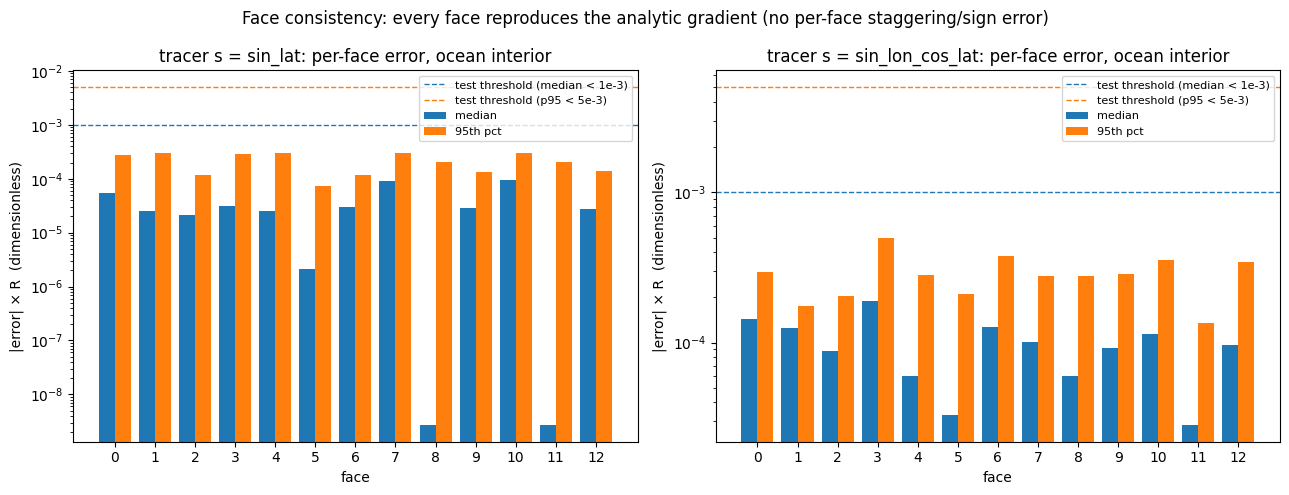

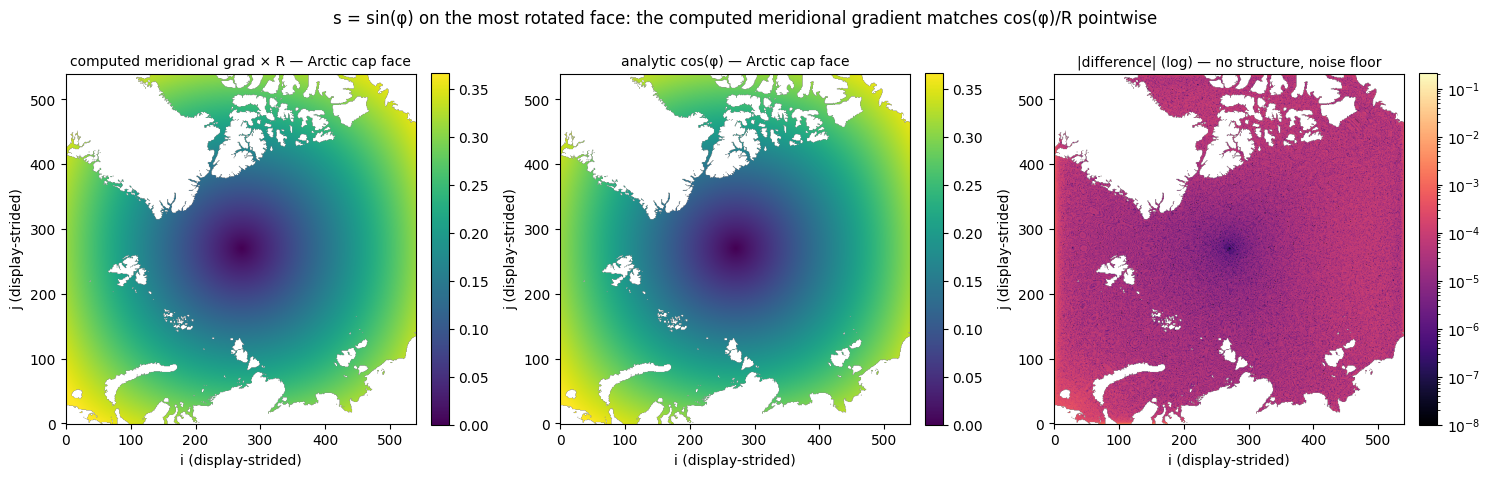

In [ ]:
ocean_int = tgt.interior(gr['hFacC']).values > 0
stats = {}
maps_arctic = None
ARCTIC = 6                                       # the Arctic cap face
for kind in ('sin_lat', 'sin_lon_cos_lat'):
    s_np, gz_np, gm_np = tgt.analytic_geographic_gradient(
        kind, gr['XC'].values, gr['YC'].values)
    s_da = xr.DataArray(
        s_np, dims=('face', 'j', 'i'),
        coords={c: gr.coords[c] for c in ('face', 'j', 'i')})
    glr, gpr = ng.calculate_native_gradient_tracer(s_da, gr, grid_r)
    ez = (tgt.interior(glr).values - tgt.interior(
        xr.DataArray(gz_np, dims=('face', 'j', 'i'))).values
        ) * tgt.R_SPHERE
    em = (tgt.interior(gpr).values - tgt.interior(
        xr.DataArray(gm_np, dims=('face', 'j', 'i'))).values
        ) * tgt.R_SPHERE
    med, p95 = [], []
    for f in range(13):
        m = ocean_int[f]
        pooled = np.concatenate([np.abs(ez[f][m]), np.abs(em[f][m])])
        pooled = pooled[np.isfinite(pooled)]
        med.append(np.median(pooled))
        p95.append(np.percentile(pooled, 95.0))
    stats[kind] = (med, p95)
    if kind == 'sin_lat':
        stride = 8                               # display only
        comp = gpr.isel(face=ARCTIC).values[::stride, ::stride]
        ana = gm_np[ARCTIC][::stride, ::stride]
        oc = gr['hFacC'].isel(face=ARCTIC).values[::stride, ::stride] > 0
        maps_arctic = (np.where(oc, comp, np.nan) * tgt.R_SPHERE,
                       np.where(oc, ana, np.nan) * tgt.R_SPHERE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xf = np.arange(13)
for ax, kind in zip(axes, ('sin_lat', 'sin_lon_cos_lat')):
    med, p95 = stats[kind]
    ax.bar(xf - 0.2, med, width=0.4, label='median', color='C0')
    ax.bar(xf + 0.2, p95, width=0.4, label='95th pct', color='C1')
    ax.axhline(1e-3, color='C0', ls='--', lw=1,
               label='test threshold (median < 1e-3)')
    ax.axhline(5e-3, color='C1', ls='--', lw=1,
               label='test threshold (p95 < 5e-3)')
    ax.set_yscale('log')
    ax.set_xticks(xf)
    ax.set_xlabel('face')
    ax.set_ylabel('|error| × R  (dimensionless)')
    ax.set_title(f'tracer s = {kind}: per-face error, ocean interior')
    ax.legend(fontsize=8)
fig.suptitle('Face consistency: every face reproduces the analytic '
             'gradient (no per-face staggering/sign error)')
fig.tight_layout()
plt.show()

comp_m, ana_m = maps_arctic
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
vmax = np.nanpercentile(np.abs(ana_m), 99.9)
for ax, img, title in zip(
        axes[:2], (comp_m, ana_m),
        ('computed meridional grad × R', 'analytic cos(φ)')):
    pcm = ax.imshow(img, origin='lower', cmap='viridis', vmin=0,
                    vmax=vmax)
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title + ' — Arctic cap face', fontsize=10)
diff = np.abs(comp_m - ana_m)
pcm = axes[2].imshow(np.clip(diff, 1e-8, None), origin='lower',
                     cmap='magma', norm=LogNorm())
fig.colorbar(pcm, ax=axes[2], fraction=0.046, pad=0.04)
axes[2].set_title('|difference| (log) — no structure, noise floor',
                  fontsize=10)
for ax in axes:
    ax.set_xlabel('i (display-strided)')
    ax.set_ylabel('j (display-strided)')
fig.suptitle('s = sin(φ) on the most rotated face: the computed '
             'meridional gradient matches cos(φ)/R pointwise')
fig.tight_layout()
plt.show()


## 8. Magnitude invariance under rotation

**What we're testing:** that rotating the gradient vector preserves its
magnitude — `|∇s|` in the geographic frame equals `|∇s|` in the model frame.
The same real tracer is run twice, once with the real `CS`/`SN` and once with
the rotation forced to the identity, compared pointwise.

**How to tell it worked:** the scatter sits on `y = x`, the printed fraction of
bit-identical points is high, and the RMS-difference line sits far below the
signal-RMS line.

**What this actually constrains.** The rotation is applied *after* the
differencing, so the two magnitudes agree if and only if `CS² + SN² = 1` in the
stored grid. This is a useful integrity check on the **grid file**, not on the
gradient computation: it cannot detect a wrong staggering point, a wrong
metric, or swapped components. Section 7 is the test that constrains those.


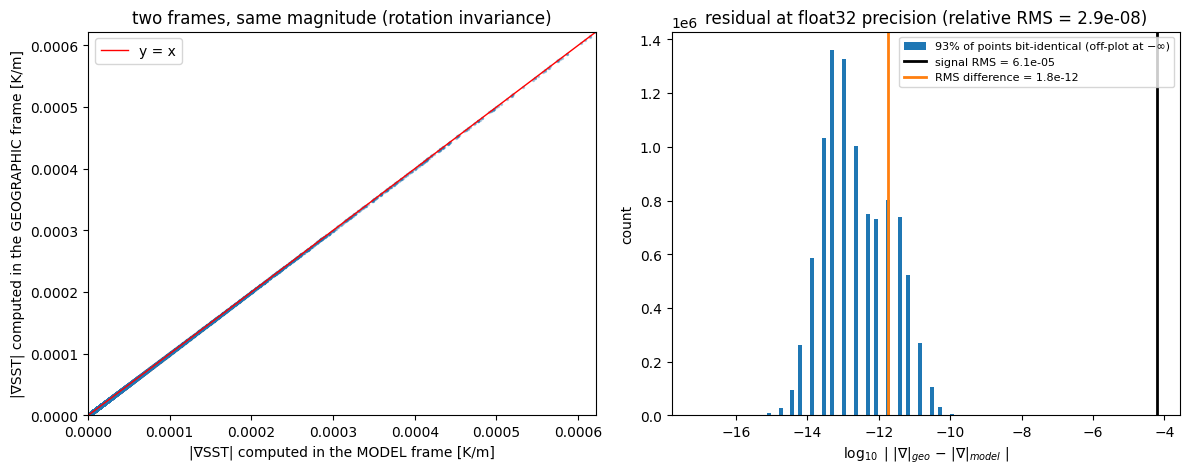

In [ ]:
g = tgt.interior(mag_g).values[ocean_int]
m_ = tgt.interior(mag_m).values[ocean_int]
fin = np.isfinite(g) & np.isfinite(m_)
g, m_ = g[fin], m_[fin]
diff = np.abs(g - m_).astype('float64')
srms = np.sqrt(np.mean(m_.astype('float64') ** 2))
drms = np.sqrt(np.mean(diff ** 2))

rng = np.random.default_rng(0)
idx = rng.choice(g.size, size=min(40000, g.size), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(m_[idx], g[idx], s=2, alpha=0.3)
lim = np.nanpercentile(m_, 99.9)
axes[0].plot([0, lim], [0, lim], 'r-', lw=1, label='y = x')
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_xlabel('|∇SST| computed in the MODEL frame [K/m]')
axes[0].set_ylabel('|∇SST| computed in the GEOGRAPHIC frame [K/m]')
axes[0].set_title('two frames, same magnitude (rotation invariance)')
axes[0].legend()

zero_frac = np.mean(diff == 0.0)
dpos = diff[diff > 0]
axes[1].hist(np.log10(dpos), bins=70,
             label=f'{zero_frac:.0%} of points bit-identical '
                   '(off-plot at −∞)')
axes[1].axvline(np.log10(srms), color='k', lw=2,
                label=f'signal RMS = {srms:.1e}')
axes[1].axvline(np.log10(drms), color='C1', lw=2,
                label=f'RMS difference = {drms:.1e}')
axes[1].set_xlabel(r'$\log_{10}$ | |∇|$_{geo}$ − |∇|$_{model}$ |')
axes[1].set_ylabel('count')
axes[1].set_title(f'residual at float32 precision '
                  f'(relative RMS = {drms / srms:.1e})')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## What these tests do NOT cover

* **Coastlines.** The routine differences the raw tracer array with no land
  mask, so the first ocean cell in from any coast is differenced against the
  land fill value. Every analytic test field here is smooth across the
  coastline, so **no test exercises a coastal cell.** Mask or erode one cell in
  from land before using these gradients near coasts.
* **Partial cells.** `hFacC` is used as a binary mask only, never as a
  fractional weight.
* **Time.** Single snapshot throughout; nothing checks broadcasting over time.
* **Output units and grid-location attributes.** Not attached, not asserted —
  "output is at tracer points" is a documentation promise, not an enforced one.
* **An independent implementation.** Everything is checked against closed-form
  fields, not a second code path.
* **A uniform scaling error in both metrics** (Section 4).
* **Downstream combinations.** Squaring, multiplying or re-interpolating these
  gradients has its own artifacts — see `docs/Gradients.md`. Nothing here
  covers them.


## 9. Run the test suite

Runs every check in `tests/test_native_gradient_tracer.py`, offline first then
online. Two "passed" lines is the result; a raised error is the failure.


In [ ]:
tgt.test_tracer_no_rotation_recovers_model_gradient()
tgt.test_tracer_90deg_rotation_sign_conventions()
tgt.test_tracer_constant_field_zero_gradient()
for a_deg in (0.0, 30.0, 45.0, 90.0, 137.0):
    tgt.test_tracer_general_angle_matches_rotation(a_deg)
for a_deg in (0.0, 30.0):
    tgt.test_tracer_anisotropic_grid_metrics(a_deg)
tgt.test_tracer_output_coordinate_contract()
print('offline tests passed.')

tgt.test_tracer_real_grid_constant_field_zero_gradient()
for kind in ('sin_lat', 'sin_lon_cos_lat'):
    tgt.test_tracer_real_grid_face_consistency_analytic_field(kind)
tgt.test_tracer_real_grid_gradient_magnitude_invariance()
print('online tests passed.')


offline tests passed.


online tests passed.
